## Zadanie 11 -- Multi-step forecast
Zbuduj model prognozujący 7 dni naraz (zamiast 1 dnia):
* Podejście 1: Recursive (prognozuj 1 dzień, użyj jako wejście)
* Podejście 2: Direct (osobny model na każdy dzień)
* Podejście 3: LSTM z Dense(7) na wyjściu

Porównaj błędy per horyzont (dzień 1 vs dzień 7).
Oczekiwany wynik: porównanie 3 podejść, błąd vs horyzont

In [35]:
import numpy as np
import pandas as pd
from sklearn.metrics import *
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor

## Timeseries

In [22]:
dates = pd.date_range(start='2024-01-01', end='2026-12-31', freq='D')
trend = np.linspace(1, 100, 1096)

df = pd.DataFrame({'dates': dates, 'trend': trend})
df['seasonality'] = np.sin(df.index * np.pi / 180) * 50
df['noise'] = np.random.normal(loc=5, scale=10, size=1096)
df['sales'] = round(df.trend + df.seasonality + df.noise,2)
sales = pd.DataFrame({'sales': df['sales'].values}, index=dates)

for i in range(1, 8):
    sales[f'lag_{i}'] = sales['sales'].shift(i)

np.random.seed = 42
sales = sales.dropna()
sales

,sales,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
2024-01-08,9.12,-3.52,12.41,11.57,1.02,22.15,2.32,8.29
2024-01-09,14.34,9.12,-3.52,12.41,11.57,1.02,22.15,2.32
2024-01-10,9.67,14.34,9.12,-3.52,12.41,11.57,1.02,22.15
2024-01-11,13.85,9.67,14.34,9.12,-3.52,12.41,11.57,1.02
2024-01-12,0.73,13.85,9.67,14.34,9.12,-3.52,12.41,11.57
...,...,...,...,...,...,...,...,...
2026-12-27,120.66,95.76,133.22,108.46,115.44,100.12,100.82,100.75
2026-12-28,121.41,120.66,95.76,133.22,108.46,115.44,100.12,100.82
2026-12-29,124.54,121.41,120.66,95.76,133.22,108.46,115.44,100.12
2026-12-30,122.72,124.54,121.41,120.66,95.76,133.22,108.46,115.44


<Axes: >

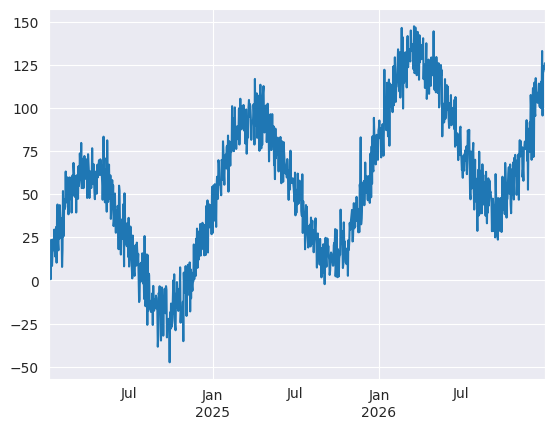

In [23]:
sales['sales'].plot()

## Recursive i Direct split

In [20]:
feature_cols = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7']
X = sales[feature_cols].values
y = np.column_stack([sales['sales'].shift(-h).values for h in range(1, 7 + 1)])

X = X[:-7]
y = y[:-7]
split = int(len(sales) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f'{X_train.shape}, {y_train.shape}, {X_test.shape}, {y_test.shape}')


(871, 7), (871, 7), (211, 7), (211, 7)


#### Recursive

In [30]:
recursive = GradientBoostingRegressor(n_estimators=200, learning_rate=0.01, max_depth=5)
recursive.fit(X_train, y_train[:, 0])
recursive_pred = np.zeros((len(X_test), 7))

for i in range(len(X_test)):
    i_lags = X_test[i].copy()
    for h in range(7):
        pred = recursive.predict(i_lags.reshape(1, -1))[0]
        recursive_pred[i, h] = pred
        i_lags = np.roll(i_lags, 1)
        i_lags[0] = pred


mae_recursive = [mean_absolute_error(y_test[:, h], recursive_pred[:, h]) for h in range(7)]
mae_recursive

[9.945209054605693,
 9.864912556358085,
 10.347771401661095,
 10.759427211680084,
 11.1621316385989,
 11.820331872040676,
 12.151049304058995]

## Direct

In [36]:
models_direct = []
direct_pred = np.zeros((len(X_test), 7))

for h in range(7):
    model_h = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                         learning_rate=0.1)
    model_h.fit(X_train, y_train[:, h])
    direct_pred[:, h] = model_h.predict(X_test)
    models_direct.append(model_h)

mae_direct = [mean_absolute_error(y_test[:, h], direct_pred[:, h])
              for h in range(7)]
mae_direct

[10.176588735917182,
 10.283793147020093,
 10.518994225378156,
 10.333919246706287,
 10.860243058169605,
 11.410988934035604,
 11.525238935011497]

### LSTM

In [38]:
series_values = sales['sales'].values.reshape(-1, 1)
split = int(len(series_values) * 0.8)

scaler = MinMaxScaler()
series_train_scaled = scaler.fit_transform(series_values[:split])
series_test_scaled = scaler.transform(series_values[split:])
series_scaled = np.vstack([series_train_scaled, series_test_scaled])

seq_len = 30

def create_window(data, window, horizon):
    X, y = [], []
    for i in range(len(data) - window - horizon):
        X.append(data[i:i + window])
        y.append(data[i + window : i + window + horizon].flatten())
    return np.array(X), np.array(y)

X_seq, y_seq = create_window(series_scaled, seq_len, 7)

split_seq = int(len(X_seq) * 0.8)
X_train_l, X_test_l = X_seq[:split_seq], X_seq[split_seq:]
y_train_l, y_test_l = y_seq[:split_seq], y_seq[split_seq:]

model_lstm = tf.keras.Sequential([
    layers.LSTM(64, dropout=0.2, input_shape=(seq_len, 1)),
    layers.Dense(32, activation='relu'),
    layers.Dense(7)
])
model_lstm.compile(optimizer='adam', loss='mse')

callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
model_lstm.fit(X_train_l, y_train_l, epochs=50, batch_size=32, validation_split=0.15, callbacks=callbacks, verbose=0)

y_pred_lstm = model_lstm.predict(X_test_l, verbose=0)
y_test_orig  = np.column_stack([scaler.inverse_transform(y_test_l[:, h].reshape(-1,1)) for h in range(7)])
y_pred_orig  = np.column_stack([scaler.inverse_transform(y_pred_lstm[:, h].reshape(-1,1)) for h in range(7)])

mae_lstm = [mean_absolute_error(y_test_orig[:, h], y_pred_orig[:, h])
            for h in range(7)]
mae_lstm

/mnt/Dane_Ubuntu/PythonProjects/#Data Science Course/Wyklady/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[17.874097388389547,
 18.765917006216906,
 18.521459975039225,
 15.759385506146323,
 17.241097279408528,
 19.18868432646114,
 19.744068018113264]

### Results

In [46]:
mae_results = {'MAE Recussive': mae_recursive, 'MAE Direct': mae_direct, 'MAE LSTM': mae_lstm}
results = pd.DataFrame(mae_results, index= range(1,8))
results

,MAE Recussive,MAE Direct,MAE LSTM
1,9.945209,10.176589,17.874097
2,9.864913,10.283793,18.765917
3,10.347771,10.518994,18.521460
4,10.759427,10.333919,15.759386
5,11.162132,10.860243,17.241097
6,11.820332,11.410989,19.188684
7,12.151049,11.525239,19.744068


<Axes: >

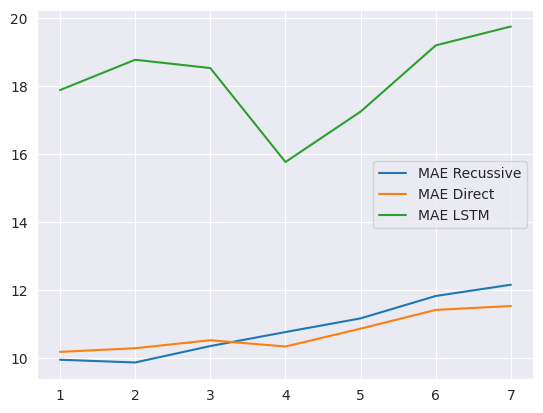

In [47]:
results.plot()